In [10]:
import numpy as np
import pandas as pd

import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures, FunctionTransformer, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error, r2_score

class LinearRegressions2:
    def __init__(self, df_train:pd.DataFrame, df_test:pd.DataFrame):
        self.df_train = df_train
        self.df_test = df_test
        self.features = df_train.columns
        self.models = {}

    def fit(self,features,degree=2,interaction=True,trig=False):
        #Initialize entries
        self.models.setdefault(degree,{})
        self.models[degree].setdefault(interaction,{})
        self.models[degree][interaction].setdefault(trig,{})

        X_train = self.df_train[features]
        y_train = self.df_train["solar"]

        if trig: #Apply cosine to the zenith angle if true
            model = Pipeline(steps=[
                ('trig_apply', ColumnTransformer(transformers=[('cos',FunctionTransformer(np.cos),['Solar Zenith Angle'])],remainder='passthrough')),
                ('poly',PolynomialFeatures(degree=degree,interaction_only=interaction)),
                ('scale',StandardScaler()),
                ('regression', LinearRegression(n_jobs=-1))])
        else: #Otherwise skip
            model = Pipeline(steps=[
                    ('poly',PolynomialFeatures(degree=degree,interaction_only=interaction)),
                    ('scale',StandardScaler()),
                    ('regression', LinearRegression(n_jobs=-1))])
            
        model.fit(X_train,y_train)

        self.models[degree][interaction][trig][tuple(features)] = model

    def get_model(self, features, degree=2,interaction=True,trig=False):
        return self.models[degree][interaction][trig][tuple(features)]
    
    def predictions(self, features, degree=2,interaction=True,trig=False):
        model = self.get_model(features,degree,interaction,trig)
        df = self.df_test[["solar"]].copy()
        df['Prediction'] = np.clip(model.predict(self.df_test[features]),0,None) #Clip negative values to 0 for minor improvement
        return df
         
    
def plot_data2(title:str,df:pd.DataFrame,day=None):
    if day is not None:#Optional day argument starts are chosen day
        start = pd.Timestamp(year=df.index.year[1],month=1,day=1).tz_localize('UTC')+pd.Timedelta(days=day-1)
        end = start+pd.Timedelta(days=14)
    else:#Otherwise randomly choose a day to begin plot
        days = [day for day in df.index.unique() if day.day_of_year < 350]
        start = np.random.choice(days)
        end = start+pd.Timedelta(days=14)

    plot_df = df.asfreq('h')#Add NaN rows so pyplot skips interpolation across jumps
    plot_df = plot_df.loc[start:end]

    #Metrics added to plot labeling
    rmse = root_mean_squared_error(df['solar'],df['Prediction'])
    r2 = r2_score(df['solar'],df['Prediction'])

    plt.figure(figsize=(20, 5))
    plt.plot(plot_df.index, plot_df['solar'], label='Actual solar', alpha=0.5)
    plt.plot(plot_df.index, plot_df['Prediction'], label='Predicted Energy', linestyle='--', alpha=0.9)
    plt.title(f"Actual vs Predicted Solar Energy in CO over Time ({title})")
    plt.xlabel("Time")
    plt.ylabel("Solar Energy CO")
    plt.text(0.94,1.05,f'RMSE: {rmse:.2f}\n r2: {r2:.4f}',transform=plt.gca().transAxes,bbox=dict(boxstyle="square", facecolor="white"))
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

   

def plot_daily_data2(title:str,df:pd.DataFrame):
    #Convert dataframe of hourly data to daily data of total energy
    df_daily = df.resample('d').agg('sum')

    #Metrics added to plot labeling
    rmse = root_mean_squared_error(df_daily['solar'],df_daily['Prediction'])
    r2 = r2_score(df_daily['solar'],df_daily['Prediction'])

    plt.figure(figsize=(20, 5))
    sns.scatterplot(df_daily, x=df_daily.index,y='solar',label='Actual Energy')
    sns.scatterplot(df_daily, x=df_daily.index,y='Prediction',label='Predicted Energy')
    plt.title(f"Actual vs Predicted Energy Over Time Daily Total ({title})")
    plt.xlabel("Time")
    plt.ylabel("Solar Energy CO per day")
    plt.text(0.94,1.05,f'RMSE: {rmse:.2f}\n r2: {r2:.4f}',transform=plt.gca().transAxes,bbox=dict(boxstyle="square", facecolor="white"))
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()  

    

In [11]:
SolarData22 = pd.read_csv('../data/Processed/Solar2022.csv',index_col=0,parse_dates=[0])
SolarData23 = pd.read_csv('../data/Processed/Solar2023.csv',index_col=0,parse_dates=[0])
SolarData24 = pd.read_csv('../data/Processed/Solar2024.csv',index_col=0,parse_dates=[0])

co22 = pd.read_csv('../data/Processed/co22.csv',index_col=0,parse_dates=[0])
co23 = pd.read_csv('../data/Processed/co23.csv',index_col=0,parse_dates=[0])
co24 = pd.read_csv('../data/Processed/co24.csv',index_col=0,parse_dates=[0])

combined_2022 = SolarData22.join(co22, how='inner')
combined_2023 = SolarData23.join(co23, how='inner')
combined_2024 = SolarData24.join(co24, how='inner')

comDay22 = combined_2022[combined_2022['Solar Zenith Angle']<np.pi/2]
comDay23 = combined_2023[combined_2023['Solar Zenith Angle']<np.pi/2]
comDay24 = combined_2024[combined_2024['Solar Zenith Angle']<np.pi/2]

comDay22.loc[:, 'capacity'] = 1871.5
comDay23.loc[:,'capacity']= 2167.5
comDay24.loc[:, 'capacity']= 2170.9


comDay24= comDay24.interpolate(method='linear')
comDay23= comDay23.interpolate(method='linear')
comDay22= comDay22.interpolate(method='linear')

C:\Users\jumo2729\AppData\Local\Temp\ipykernel_8096\3703937788.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  comDay22.loc[:, 'capacity'] = 1871.5
C:\Users\jumo2729\AppData\Local\Temp\ipykernel_8096\3703937788.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  comDay23.loc[:,'capacity']= 2167.5
C:\Users\jumo2729\AppData\Local\Temp\ipykernel_8096\3703937788.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = valu

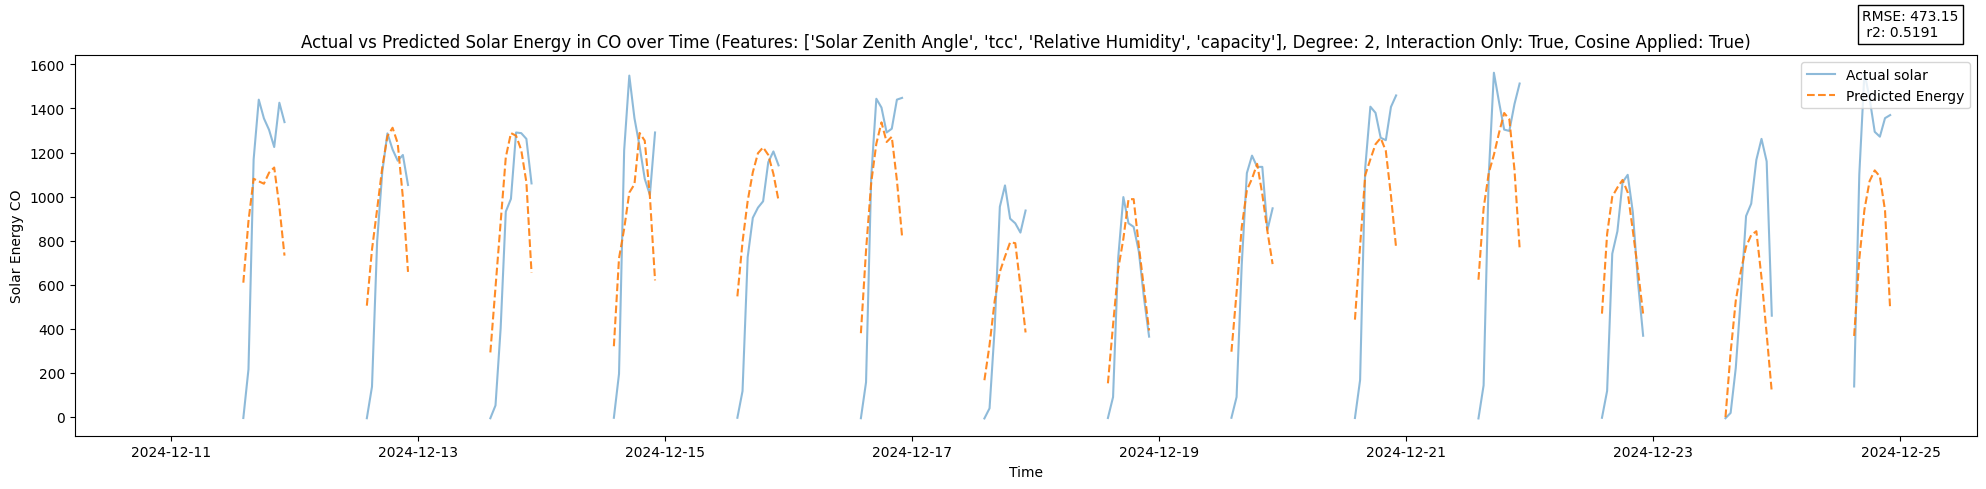

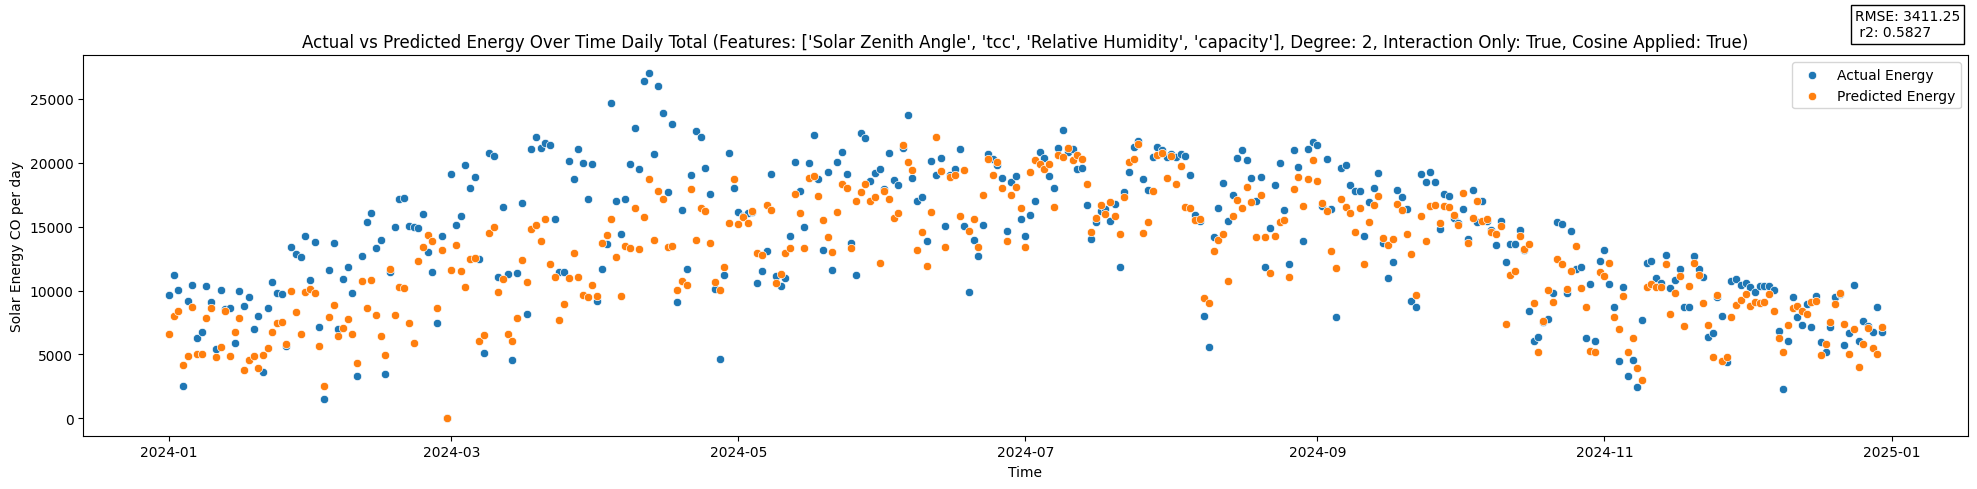

In [12]:
train_data = pd.concat([comDay22, comDay23])

LinearModels2 = LinearRegressions2(train_data,comDay24)

key = (['Solar Zenith Angle', 'tcc','Relative Humidity', 'capacity' ],2, True, True)
LinearModels2.fit(*key)
plot_data2('Features: {}, Degree: {}, Interaction Only: {}, Cosine Applied: {}'.format(*key),LinearModels2.predictions(*key))
plot_daily_data2('Features: {}, Degree: {}, Interaction Only: {}, Cosine Applied: {}'.format(*key),LinearModels2.predictions(*key))


In [6]:
comDay22Lags = comDay22.copy()
comDay23Lags = comDay23.copy()
comDay24Lags = comDay24.copy()
for lag in [1,6,24,48,72]:
    comDay22Lags[f'Energy Lag {lag}'] = comDay22Lags['solar'].shift(lag)
    comDay23Lags[f'Energy Lag {lag}'] = comDay23Lags['solar'].shift(lag)
    comDay24Lags[f'Energy Lag {lag}'] = comDay24Lags['solar'].shift(lag)
comDay22Lags.dropna(inplace=True)
comDay23Lags.dropna(inplace=True)
comDay24Lags.dropna(inplace=True)


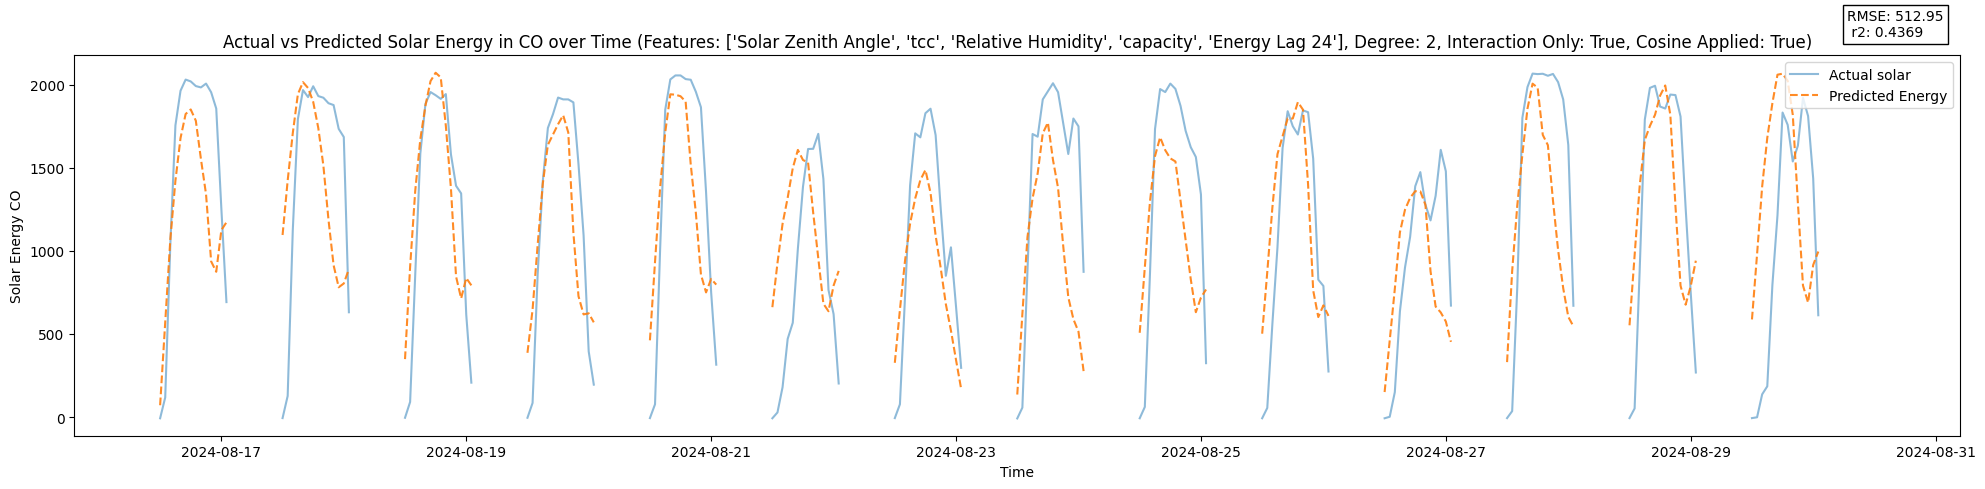

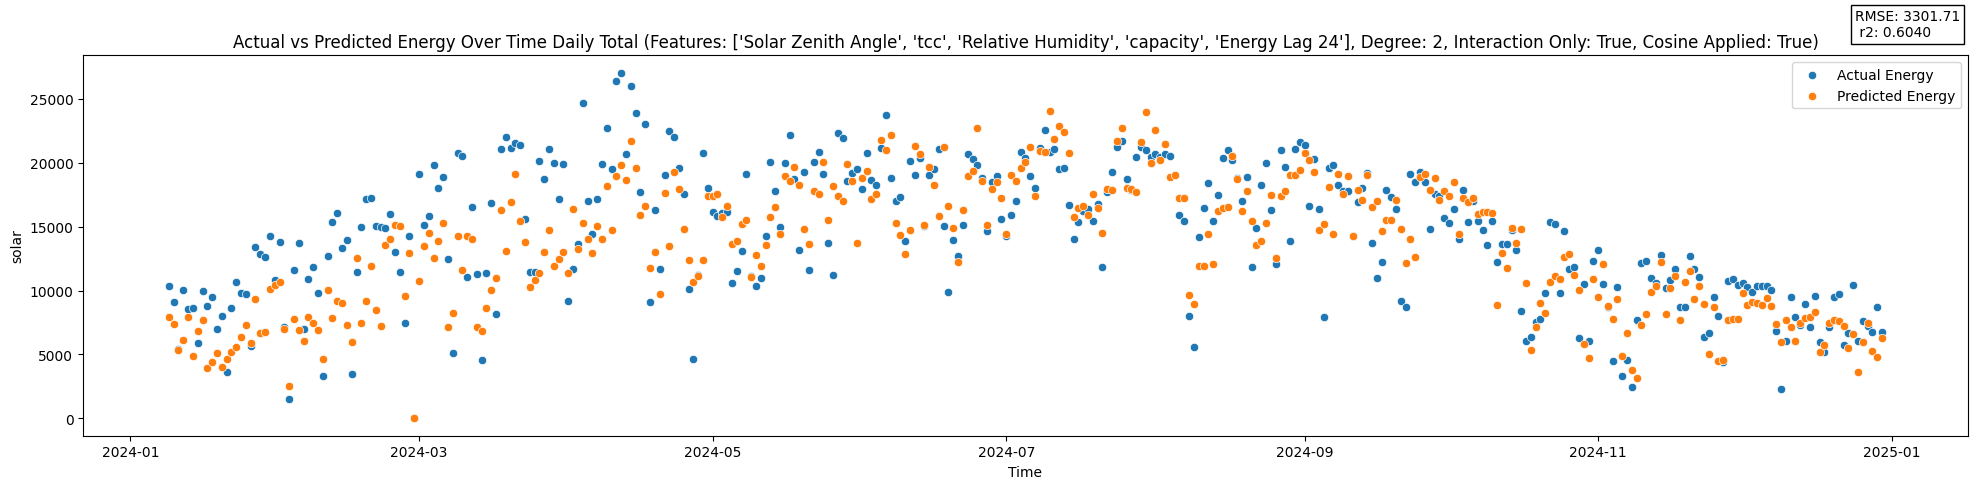

In [9]:
train_data = pd.concat([comDay22Lags, comDay23Lags])

LinearModels2 = LinearRegressions2(train_data,comDay24Lags)

key = (['Solar Zenith Angle', 'tcc', 'Relative Humidity','capacity','Energy Lag 24'],2,True, True)
LinearModels2.fit(*key)
plot_data2('Features: {}, Degree: {}, Interaction Only: {}, Cosine Applied: {}'.format(*key),LinearModels2.predictions(*key))
plot_daily_data2('Features: {}, Degree: {}, Interaction Only: {}, Cosine Applied: {}'.format(*key),LinearModels2.predictions(*key))


Net Demand

In [7]:
    
class LinearRegressions3:
    def __init__(self, df_train:pd.DataFrame, df_test:pd.DataFrame):
        self.df_train = df_train
        self.df_test = df_test
        self.features = df_train.columns
        self.models = {}

    def fit(self,features,degree=2,interaction=True,trig=False):
        #Initialize entries
        self.models.setdefault(degree,{})
        self.models[degree].setdefault(interaction,{})
        self.models[degree][interaction].setdefault(trig,{})

        X_train = self.df_train[features]
        y_train = self.df_train["net"]

        if trig: #Apply cosine to the zenith angle if true
            model = Pipeline(steps=[
                ('trig_apply', ColumnTransformer(transformers=[('cos',FunctionTransformer(np.cos),['Solar Zenith Angle'])],remainder='passthrough')),
                ('poly',PolynomialFeatures(degree=degree,interaction_only=interaction)),
                ('scale',StandardScaler()),
                ('regression', LinearRegression(n_jobs=-1))])
        else: #Otherwise skip
            model = Pipeline(steps=[
                    ('poly',PolynomialFeatures(degree=degree,interaction_only=interaction)),
                    ('scale',StandardScaler()),
                    ('regression', LinearRegression(n_jobs=-1))])
            
        model.fit(X_train,y_train)

        self.models[degree][interaction][trig][tuple(features)] = model

    def get_model(self, features, degree=2,interaction=True,trig=False):
        return self.models[degree][interaction][trig][tuple(features)]
    
    def predictions(self, features, degree=2,interaction=True,trig=False):
        model = self.get_model(features,degree,interaction,trig)
        df = self.df_test[["net"]].copy()
        df['Prediction'] = np.clip(model.predict(self.df_test[features]),0,None) #Clip negative values to 0 for minor improvement
        return df
  
def plot_data3(title:str,df:pd.DataFrame,day=None):
    if day is not None:#Optional day argument starts are chosen day
        start = pd.Timestamp(year=df.index.year[1],month=1,day=1).tz_localize('UTC')+pd.Timedelta(days=day-1)
        end = start+pd.Timedelta(days=14)
    else:#Otherwise randomly choose a day to begin plot
        days = [day for day in df.index.unique() if day.day_of_year < 350]
        start = np.random.choice(days)
        end = start+pd.Timedelta(days=14)
    plot_df = df.asfreq('h')#Add NaN rows so pyplot skips interpolation across jumps
    plot_df = plot_df.loc[start:end]

    #Metrics added to plot labeling
    rmse = root_mean_squared_error(df['net'],df['Prediction'])
    r2 = r2_score(df['net'],df['Prediction'])

    plt.figure(figsize=(20, 5))
    plt.plot(plot_df.index, plot_df['net'], label='Net Demand', alpha=0.5)
    plt.plot(plot_df.index, plot_df['Prediction'], label='Predicted Energy', linestyle='--', alpha=0.9)
    plt.title(f"Actual vs Predicted Solar Energy in CO over Time ({title})")
    plt.xlabel("Time")
    plt.ylabel("Net demand CO")
    plt.text(0.94,1.05,f'RMSE: {rmse:.2f}\n r2: {r2:.4f}',transform=plt.gca().transAxes,bbox=dict(boxstyle="square", facecolor="white"))
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

def plot_daily_data3(title:str,df:pd.DataFrame):
    #Convert dataframe of hourly data to daily data of total energy
    df_daily = df.resample('d').agg('sum')

    #Metrics added to plot labeling
    rmse = root_mean_squared_error(df_daily['net'],df_daily['Prediction'])
    r2 = r2_score(df_daily['net'],df_daily['Prediction'])

    plt.figure(figsize=(20, 5))
    sns.scatterplot(df_daily, x=df_daily.index,y='net',label='Actual Energy')
    sns.scatterplot(df_daily, x=df_daily.index,y='Prediction',label='Predicted Energy')
    plt.title(f"Actual vs Predicted Net Demand Over Time Daily Total ({title})")
    plt.xlabel("Time")
    plt.ylabel("net")
    plt.text(0.94,1.05,f'RMSE: {rmse:.2f}\n r2: {r2:.4f}',transform=plt.gca().transAxes,bbox=dict(boxstyle="square", facecolor="white"))
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()  

Net demand = total energy -solar energy

In [8]:
comDay22['net'] = comDay22['demand'] - comDay22['solar']
comDay23['net'] = comDay23['demand'] - comDay23['solar']
comDay24['net'] = comDay24['demand'] - comDay24['solar']

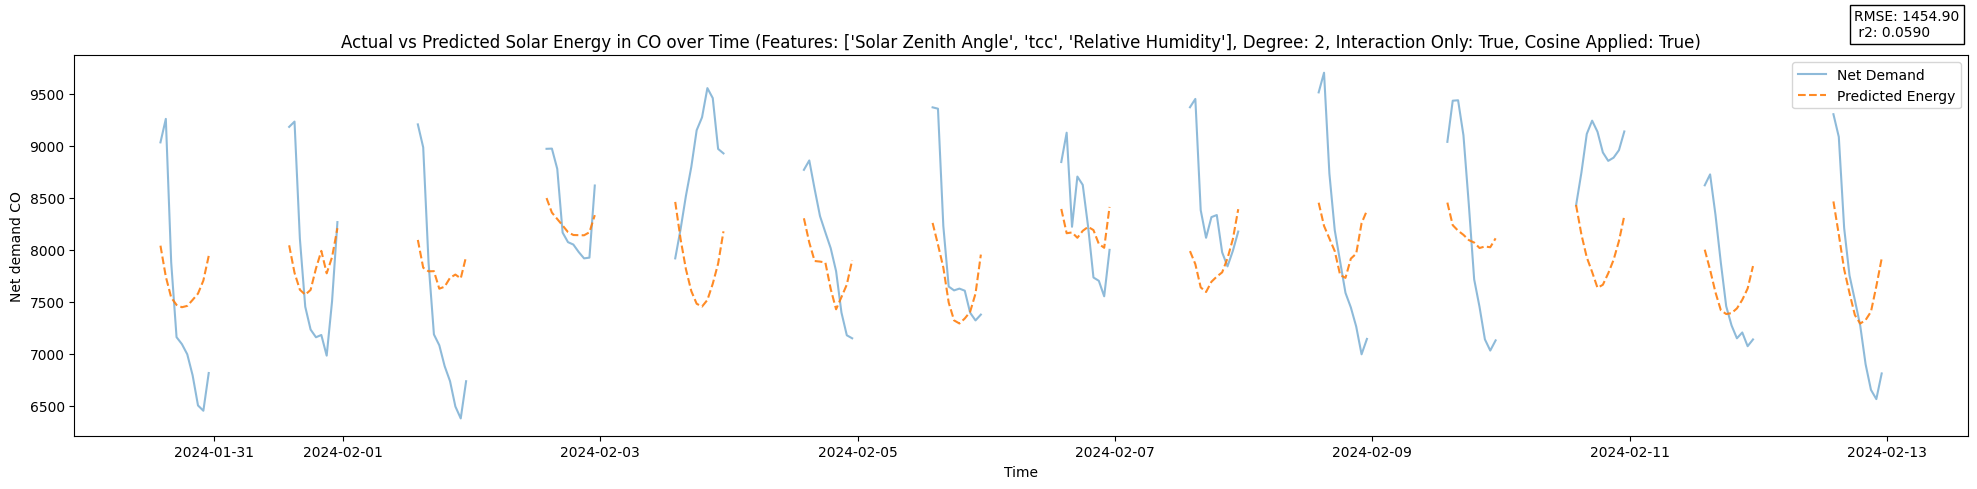

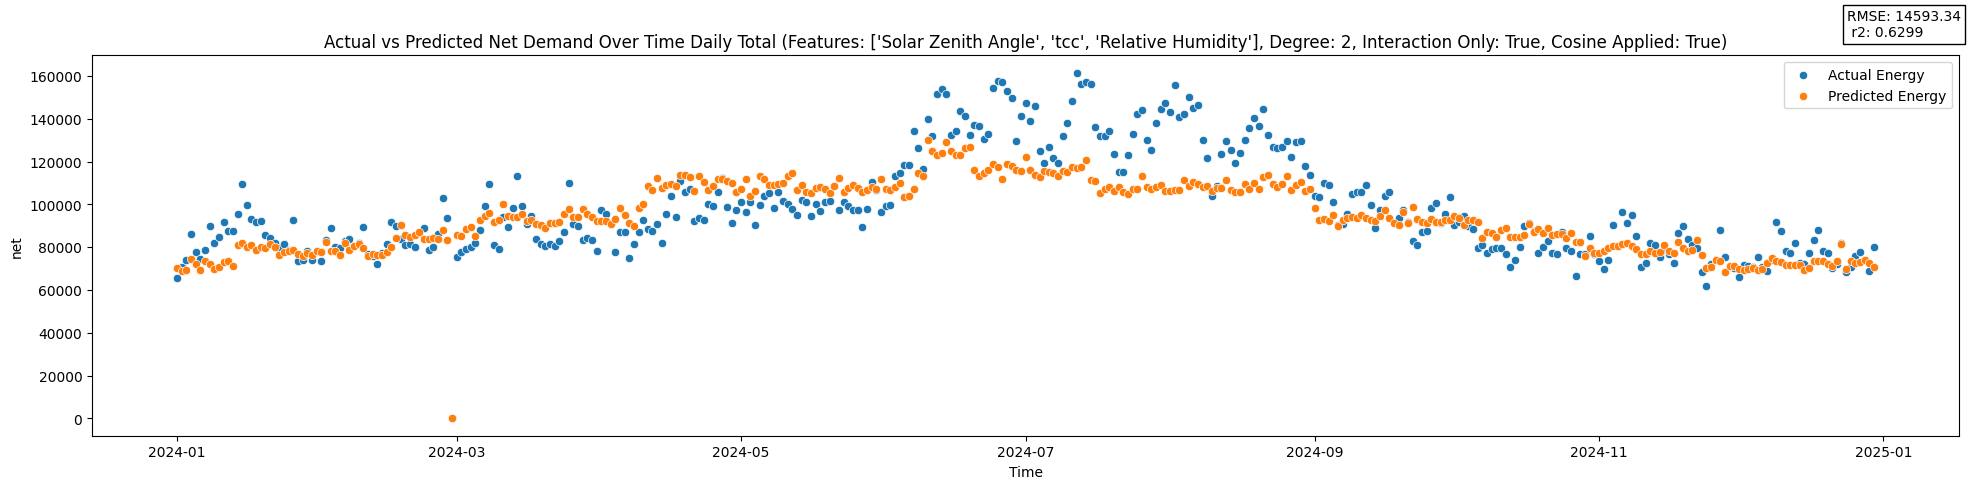

In [9]:
LinearModels3 = LinearRegressions3(comDay23,comDay24)

key = (['Solar Zenith Angle','tcc','Relative Humidity' ],2,True, True)
LinearModels3.fit(*key)
plot_data3('Features: {}, Degree: {}, Interaction Only: {}, Cosine Applied: {}'.format(*key),LinearModels3.predictions(*key),30)
plot_daily_data3('Features: {}, Degree: {}, Interaction Only: {}, Cosine Applied: {}'.format(*key),LinearModels3.predictions(*key))


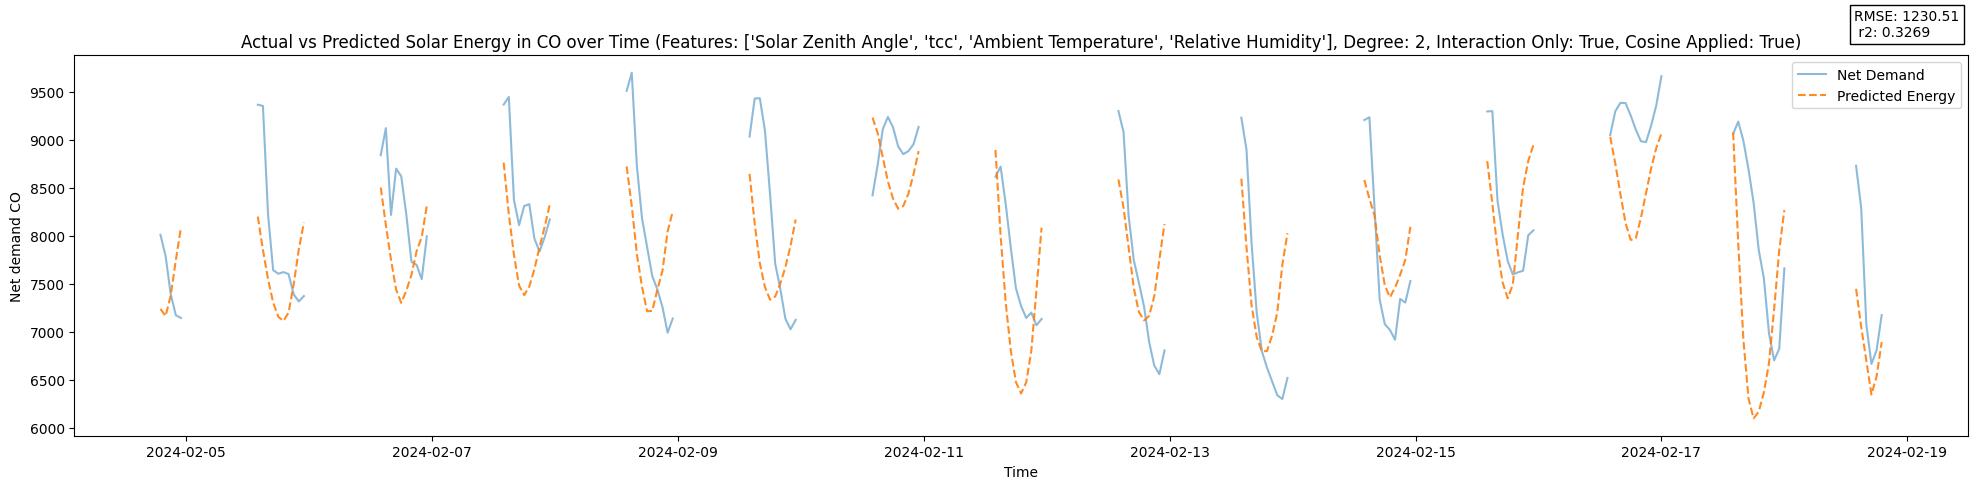

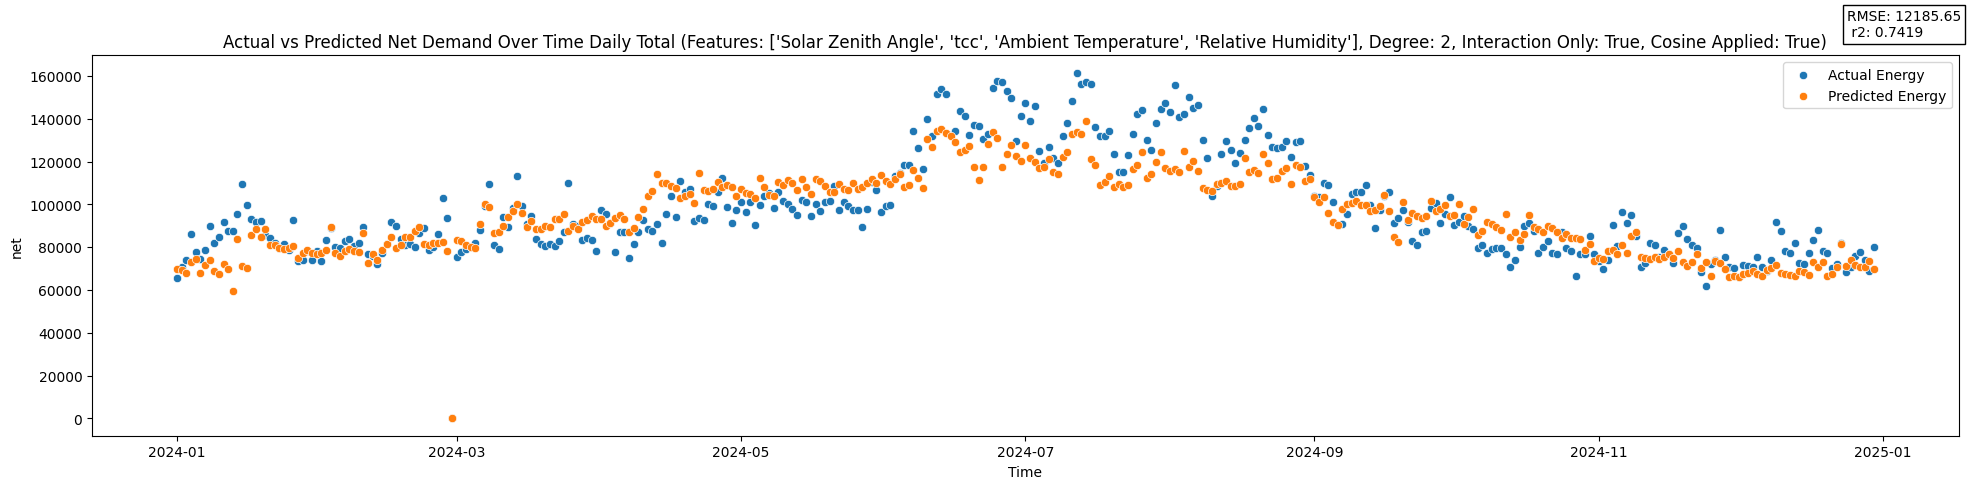

In [11]:
LinearModels3 = LinearRegressions3(comDay23,comDay24)

key = (['Solar Zenith Angle','tcc', 'Ambient Temperature','Relative Humidity' ],2,True, True)
LinearModels3.fit(*key)
plot_data3('Features: {}, Degree: {}, Interaction Only: {}, Cosine Applied: {}'.format(*key),LinearModels3.predictions(*key))
plot_daily_data3('Features: {}, Degree: {}, Interaction Only: {}, Cosine Applied: {}'.format(*key),LinearModels3.predictions(*key))


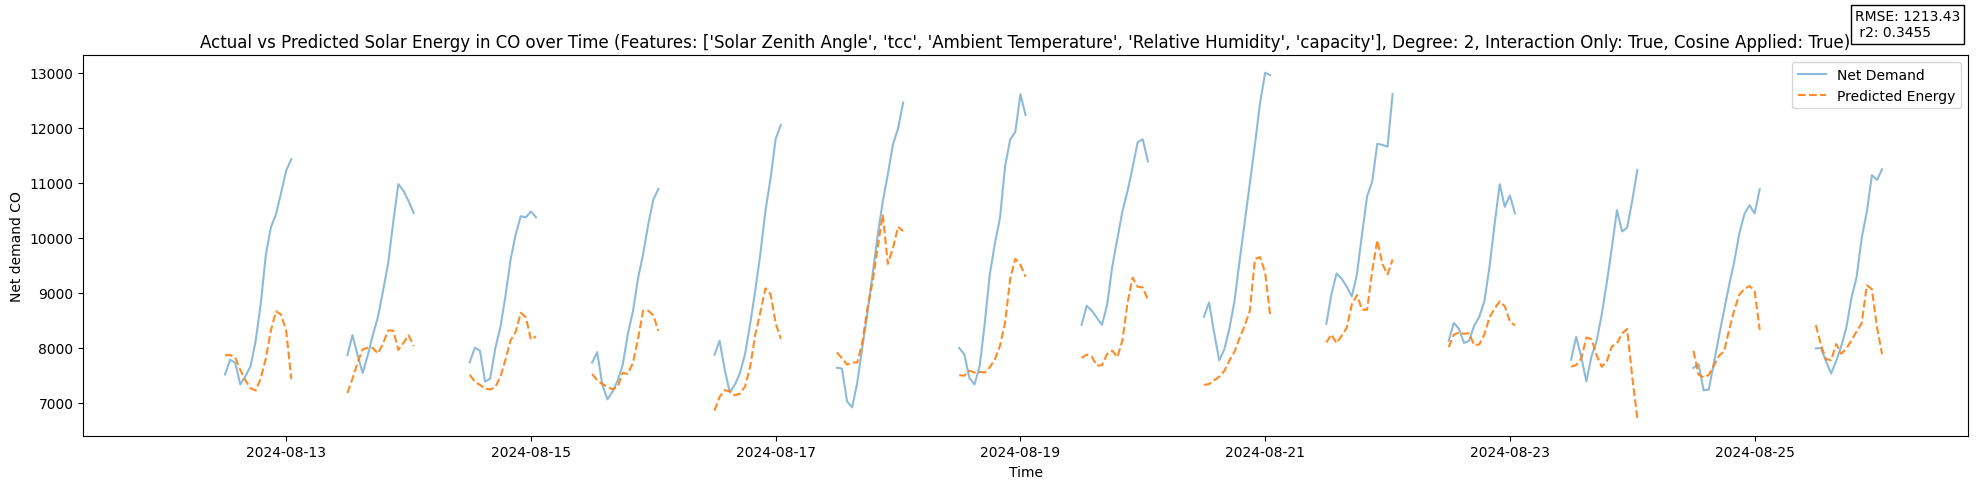

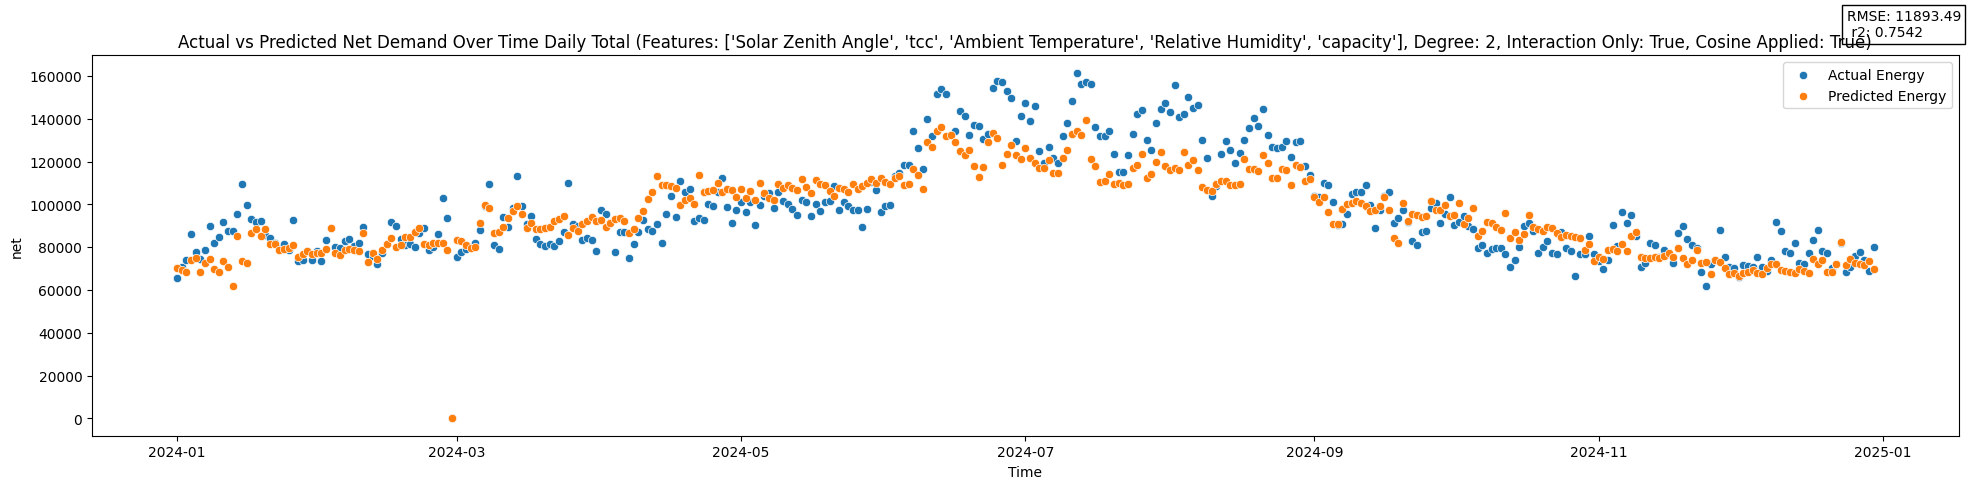

In [12]:
train_data = pd.concat([comDay22, comDay23])

LinearModels3 = LinearRegressions3(train_data,comDay24)

key = (['Solar Zenith Angle', 'tcc', 'Ambient Temperature', 'Relative Humidity' , 'capacity' ],2, True, True)
LinearModels3.fit(*key)
plot_data3('Features: {}, Degree: {}, Interaction Only: {}, Cosine Applied: {}'.format(*key),LinearModels3.predictions(*key))
plot_daily_data3('Features: {}, Degree: {}, Interaction Only: {}, Cosine Applied: {}'.format(*key),LinearModels3.predictions(*key))
